## **Fake-Real news detector using CNN model based supervised learning**
### Fernando P. T. V. A - IT22244802

In here, I am going to use the CNN model to implement the fake-real news detector using the dataset which contains near 25000 data raws.

### Step 01: Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# imports needed
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Clean and Encode Labels
from sklearn.preprocessing import LabelEncoder

# Split Train/Test sets
from sklearn.model_selection import train_test_split

# Tokenize and Pad Texts
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Build CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Train the Model
from tensorflow.keras.callbacks import EarlyStopping

# Confusion Matrix and Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ROC curve and AUC score
from sklearn.metrics import roc_curve, roc_auc_score


In [3]:
# Path for the dataset in Google Drive
data_path = "/content/drive/MyDrive/Colab Notebooks/DL Final Assignment - Fake real news detector/improved_fake_news_dataset2.csv"

### Step 02: Load the dataset

In [4]:
df = pd.read_csv(data_path)

print("Dataset shape: ", df.shape)
print("\nColumns: ", df.columns)
df.head()

# Keep only rhe "text" and "label" columns
df = df[['text', 'label']]

# Drop missing values
df.dropna(inplace=True)

print("\nAfter cleaning: ", df.shape)
df.head()

Dataset shape:  (123954, 4)

Columns:  Index(['id', 'title', 'text', 'label'], dtype='object')

After cleaning:  (123954, 2)


,text,label
0,Embargo on Phillipines - withdraw our military...,1
1,too win central main bag save common she famil...,1
2,Russian oil giant Rosneft to restore Romanov p...,1
3,the club world cup is here our representative ...,0
4,"the ismaili club s board of directors, headed ...",1


### Step 03: Clean and Encode Labels

In [6]:
# Reload dataset to avoid prior transformations
df = pd.read_csv(data_path)

# Inspect column names
print("Columns in dataset:", df.columns.tolist())

# Make sure your dataset has 'text' and 'label' columns
df = df[['text', 'label']]

# Drop missing values
df.dropna(subset=['text', 'label'], inplace=True)

# Ensure labels are strings before processing
df['label'] = df['label'].astype(str).str.lower().str.strip()

# Display unique label values before filtering
print("\nUnique raw labels:", df['label'].unique())

# Keep only 'real' and 'fake' classes (if others exist)
df = df[df['label'].isin(['real', 'fake', '1', '0'])]

# Normalize labels: map possible variants to consistent text
df['label'] = df['label'].replace({'1': 'real', '0': 'fake', 'true': 'real', 'false': 'fake'})

# Encode labels (Fake=0, Real=1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Final label check
print("\nUnique encoded labels:", df['label'].unique())
print("Encoded label distribution:\n", df['label'].value_counts())

# Optional: quick sanity check
print("\nSample data:\n", df.sample(5))

Columns in dataset: ['id', 'title', 'text', 'label']

Unique raw labels: ['1' '0']

Unique encoded labels: [1 0]
Encoded label distribution:
 label
1    61977
0    61977
Name: count, dtype: int64

Sample data:
                                                     text  label
25247  the worst match for victory, and yet he won, o...      0
35181  James Kallstrom is the former Assistant Direct...      0
53493  BOMSBHELL: Clintons Fixer PROVES That Hillary ...      1
75439  BOGOTA Reuters - Colombia s armed forces have ...      1
28083  Syria A man receives treatment at a hospital f...      1


### Step 04: Split Train/Test sets

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 99163
Testing samples: 24791


### Step 05: Tokenize and Pad Texts

In [8]:
max_words = 10000   # max vocab size
max_len = 300       # max words per news article

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("Padded training data shape:", X_train_pad.shape)

Padded training data shape: (99163, 300)


### Step 06: Build CNN model

In [25]:
from tensorflow.keras.regularizers import l2

embedding_dim = 100

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),
    Conv1D(128, 5, activation='relu', kernel_regularizer=l2(0.001)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.7),
    Dense(1, activation='sigmoid')
])

# Manually build the model so summary shows correct shapes
model.build(input_shape=(None, max_len))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 296, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,449 (4.09 MB)

 Trainable params: 1,072,449 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

### Step 07: Train the Model

In [26]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Class Weights: {0: np.float64(1.0000100845081785), 1: np.float64(0.999989915695212)}
Epoch 1/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 284s 227ms/step - accuracy: 0.7572 - loss: 0.5344 - val_accuracy: 0.8509 - val_loss: 0.3361
Epoch 2/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 294s 237ms/step - accuracy: 0.8688 - loss: 0.3186 - val_accuracy: 0.8536 - val_loss: 0.3170
Epoch 3/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 315s 232ms/step - accuracy: 0.8857 - loss: 0.2766 - val_accuracy: 0.8514 - val_loss: 0.3192
Epoch 4/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 286s 231ms/step - accuracy: 0.9035 - loss: 0.2448 - val_accuracy: 0.8501 - val_loss: 0.3364
Epoch 5/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 295s 238ms/step - accuracy: 0.9225 - loss: 0.2100 - val_accuracy: 0.8497 - val_loss: 0.3600


### Step 08: Test on New Example

In [39]:
# Find the best threshold
y_pred_probs = model.predict(X_test_pad).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold = %.3f\n' % best_thresh)

# Test on New Example
def predict_news(news_text, threshold=best_thresh):
    seq = tokenizer.texts_to_sequences([news_text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = model.predict(pad)[0][0]
    label = "Real" if pred > threshold else "Fake"
    print(f"News: {news_text}")
    print(f"🔹 Prediction: {label}")
    print(f"Probability: {pred:.3f}")

# Test usage
predict_news("NASA announced plans to send a new robotic mission to Mars by 2026 to study the planet’s surface and prepare for future human exploration, according to the agency’s statement released on Tuesday.")
print("-" * 60)
predict_news("Scientists have discovered a hidden city on the moon where aliens are living and building spaceships for an upcoming invasion of Earth, according to a secret government report.")
print("-" * 60)

# Test multiple news
sample_news = [
    "Government announces new policy to curb inflation amid rising prices.",
    "Aliens landed in New York and took selfies with tourists!"
]

for text in sample_news:
    predict_news(text)
    print("-" * 60)

775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step
Best Threshold = 0.556

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
News: NASA announced plans to send a new robotic mission to Mars by 2026 to study the planet’s surface and prepare for future human exploration, according to the agency’s statement released on Tuesday.
🔹 Prediction: Real
Probability: 0.748
------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
News: Scientists have discovered a hidden city on the moon where aliens are living and building spaceships for an upcoming invasion of Earth, according to a secret government report.
🔹 Prediction: Fake
Probability: 0.286
------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
News: Government announces new policy to curb inflation amid rising prices.
🔹 Prediction: Real
Probability: 0.837
------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
News: Aliens landed in 

### **Evaluate the CNN model**

### Step 09: Test Accuracy and Loss

Test Accuracy: 85.87%


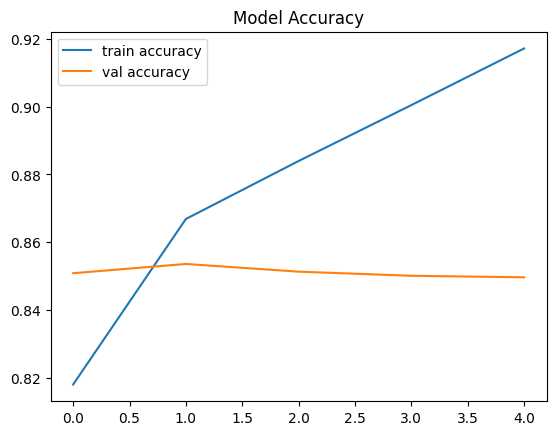

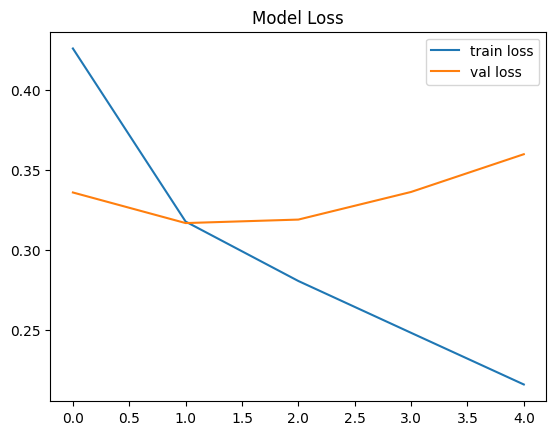

In [30]:
# Evaluate Model
import matplotlib.pyplot as plt

loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")

print("-" * 60)

# Plot training history
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Model Loss')
plt.show()

### Step 10: Confusion Matrix and Metrics (Threshold = 0.556)

775/775 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step
Model Performance Metrics
--------------------------------------------------
Accuracy           : 0.8617
Precision (macro)  : 0.8690 | Precision (weighted): 0.8690
Recall (macro)     : 0.8617 | Recall (weighted)   : 0.8617
F1-score (macro)   : 0.8610 | F1-score (weighted)  : 0.8610
--------------------------------------------------


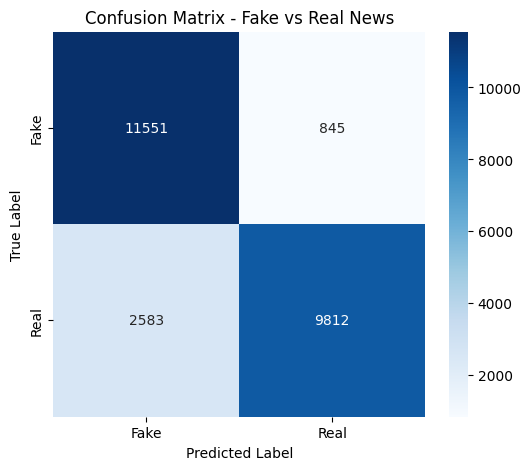

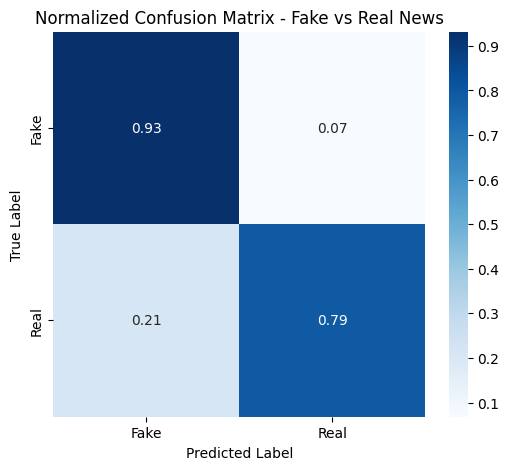

--------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

        Fake       0.82      0.93      0.87     12396
        Real       0.92      0.79      0.85     12395

    accuracy                           0.86     24791
   macro avg       0.87      0.86      0.86     24791
weighted avg       0.87      0.86      0.86     24791

--------------------------------------------------
Overall Accuracy: 0.8617240127465613


In [38]:
# Predict on the test set
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.556).astype("int32").flatten()

# Calculate core performance metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

# Print results
print("Model Performance Metrics")
print("-" * 50)
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (macro)  : {precision_macro:.4f} | Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (macro)     : {recall_macro:.4f} | Recall (weighted)   : {recall_weighted:.4f}")
print(f"F1-score (macro)   : {f1_macro:.4f} | F1-score (weighted)  : {f1_weighted:.4f}")
print("-" * 50)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Fake', 'Real']

# Display confusion matrix as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Fake vs Real News')
plt.show()

print("\n")

# Normalized confusion matrix
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix - Fake vs Real News')
plt.show()

print("-" * 50)

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=labels))
print("-" * 50)
print("Overall Accuracy:", accuracy_score(y_test, y_pred))


### Step 11: ROC curve and AUC Score

775/775 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step


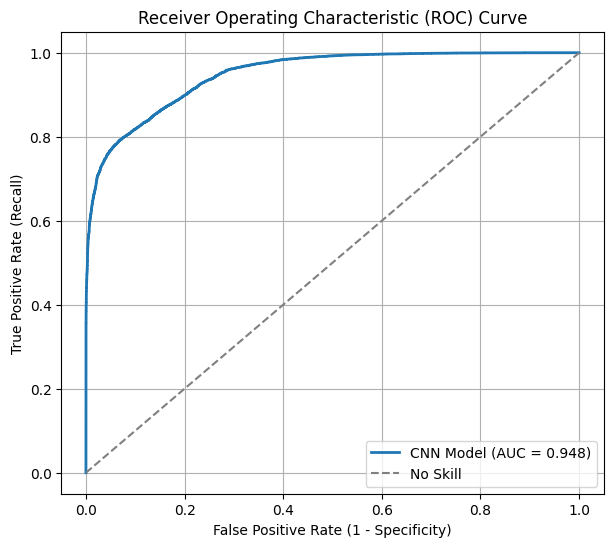


ROC-AUC Score: 0.948


In [32]:
# Get predicted probabilities for the positive class ("Real")
y_pred_probs = model.predict(X_test_pad).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'CNN Model (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No Skill')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.3f}")